# cameliND `analyze` — walkthrough

Trajectory `8DM9_1/rank0001/run1` (1000 frames, chains **A**=receptor, **B**=nanobody).

Each `analyze` method gets its own cell with its plot; the final cell runs the whole suite in one call with `all()`. Plots display inline by default (`plot(show=True, write=False)`); pass `write=True` to also save `example_<kind>.png`.

In [2]:
import logging
logging.basicConfig(level=logging.WARNING)   # quiet; set INFO to see progress
import cameliND as cam

BASE = "/net/dali/home/mscbio/rop174/cameliND/simulation/8DM9_1/rank0001/run1/"
a = cam.analyze(BASE + "model.pdb", BASE + "trajectory.dcd", outputName="example_")
print("frames:", len(a.U.trajectory), "| chains:", list(a.Chain))

frames: 1000 | chains: ['A', 'B']


/net/dali/home/mscbio/rop174/yes/envs/cameliND/lib/python3.14/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


## Preprocessing
`align()` removes rigid-body drift (here holding receptor chain A fixed).

In [3]:
a.align(chain="A")
print("aligned; frames:", len(a.U.trajectory))

aligned; frames: 1000


`downsize(percentage)` keeps every Nth frame for large trajectories. Unnecessary at 1000 frames, so shown on a throwaway object to avoid shrinking the analysis above.

In [4]:
demo = cam.analyze(BASE + "model.pdb", BASE + "trajectory.dcd", outputName="demo_")
demo.downsize(10)
print("downsized frames:", len(demo.U.trajectory))

downsized frames: 100


## Whole-protein analyses

### `rmsd()` — backbone RMSD vs first & last frame

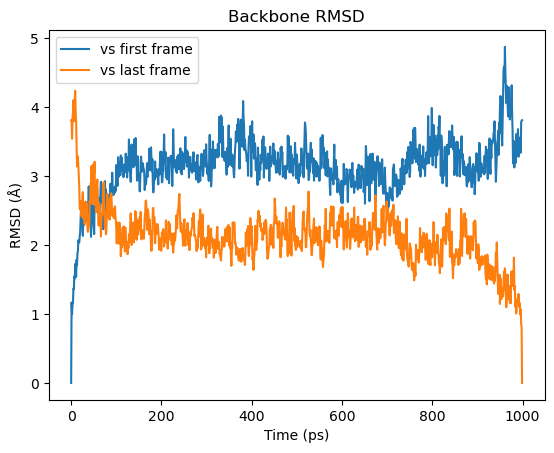

In [8]:
a.rmsd()
a.plot("rmsd");

### `rmsf()` — per-residue flexibility

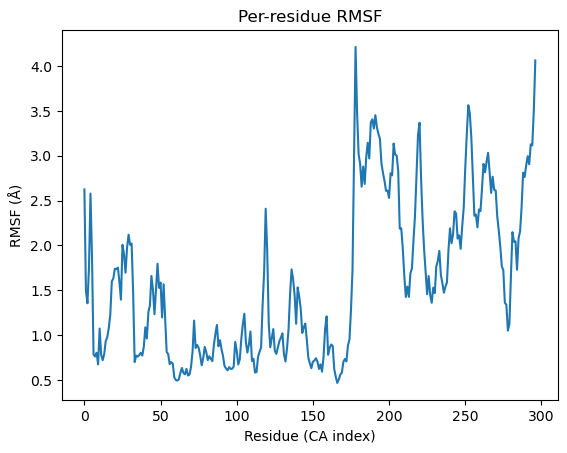

In [9]:
a.rmsf()
a.plot("rmsf");

### `pca()` — PCA of CA coordinates

In [10]:
a.pca()
print("PC array:", a.Pc.shape)

PC array: (1000, 891)


### `sfe()` — free-energy surface over PC1/PC2
ΔF runs from 0 (most-populated states, yellow) to negative (sparse background, purple). Bins are kept fine (default 200) so individual microstates aren't merged together.

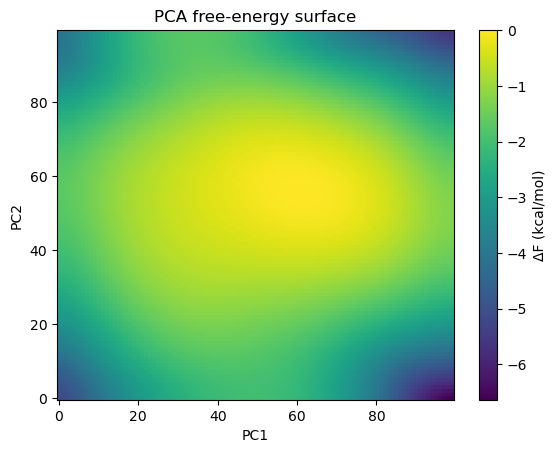

In [23]:
a.sfe(bins = 100, sigma =10)
a.plot("sfe");

### `umap()` + `clusterUmap()` — embedding and HDBSCAN clusters
`min_cluster_size` is tuned to the frame count (default 500 finds nothing in 1000 frames).

/net/dali/home/mscbio/rop174/yes/envs/cameliND/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


clusters: [np.int64(0), np.int64(1), np.int64(2)]


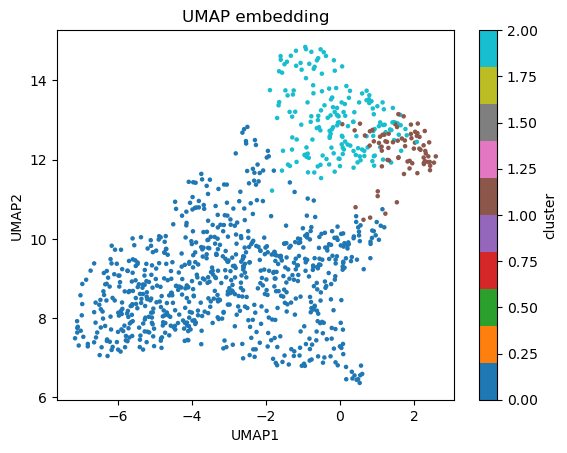

In [8]:
a.umap()
a.clusterUmap(min_cluster_size=50)
print("clusters:", sorted(set(a.Cluster)))
a.plot("umap");

### `umapSfe()` — free-energy surface over the UMAP embedding

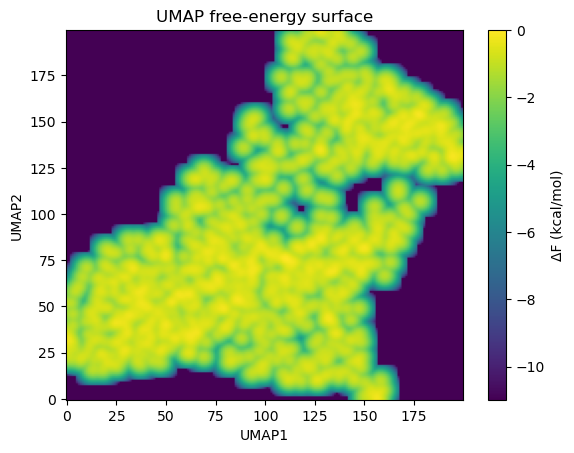

In [9]:
a.umapSfe()
a.plot("sfeUmap");

## Binding-pair analyses  (A = receptor, B = nanobody)

### `contacts()` — fraction of native contacts over time

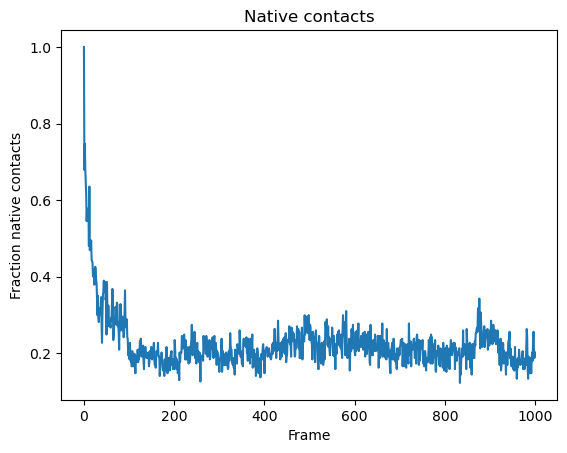

In [10]:
a.contacts("A", "B")
a.plot("contacts");

### `dist()` — mean residue–residue distance matrix

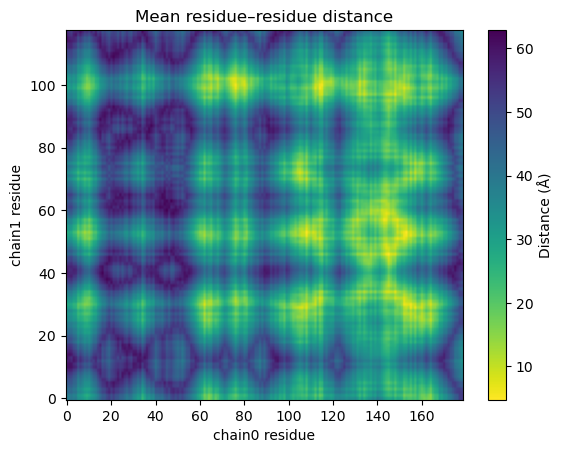

In [11]:
a.dist("A", "B")
a.plot("distance");

### `contacts2()` — per-residue-pair contact frequency

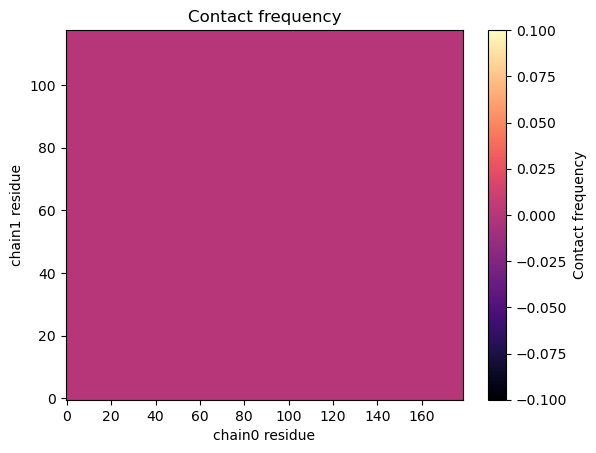

In [12]:
a.contacts2("A", "B")
a.plot("contactFreq");

### `resCor()` — inter-chain CA correlation (binding score)
`startFrame="min"` auto-trims the docking-relaxation transient (correlation is computed over the equilibrated window only); the default heatmap is condensed to the interacting residues (`view="all"` shows the full matrix).

binding score: 14.09


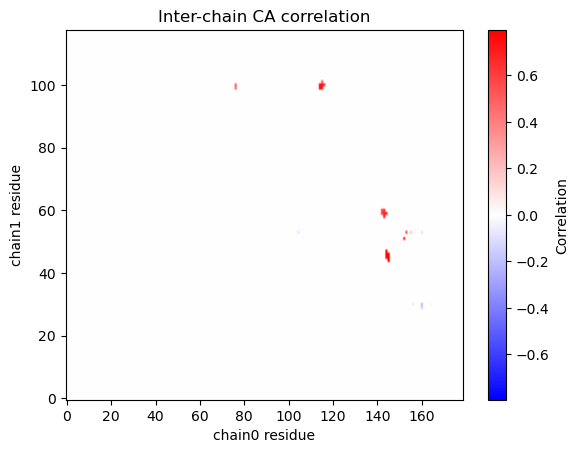

In [13]:
a.resCor("A", "B", startFrame="min")
print("trimmed from frame:", a.ResCorStartFrame, "| flagged:", a.ResCorFlagged)
print("binding score:", round(float(a.BindingScore), 2))
a.plot("resCor");            # condensed by default
a.plot("bindingScore");      # cumulative attraction/repulsion/binding vs time

## Everything at once: `all()`
The whole suite above in a single call (auto-detects the two chains), then `plotAll()` renders every result.

/net/dali/home/mscbio/rop174/yes/envs/cameliND/lib/python3.14/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


/net/dali/home/mscbio/rop174/yes/envs/cameliND/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


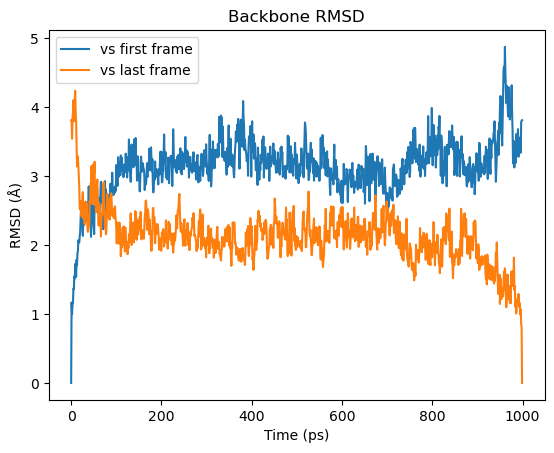

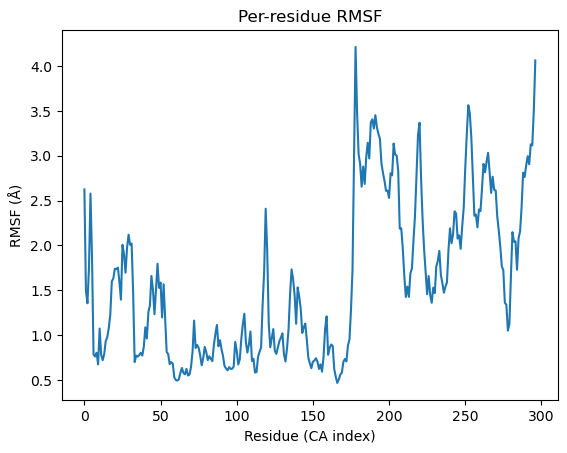

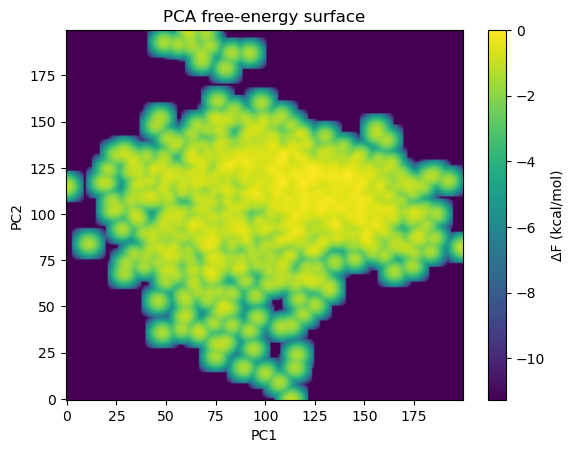

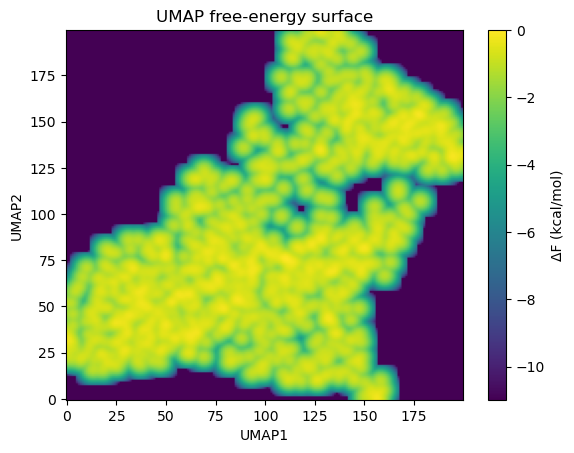

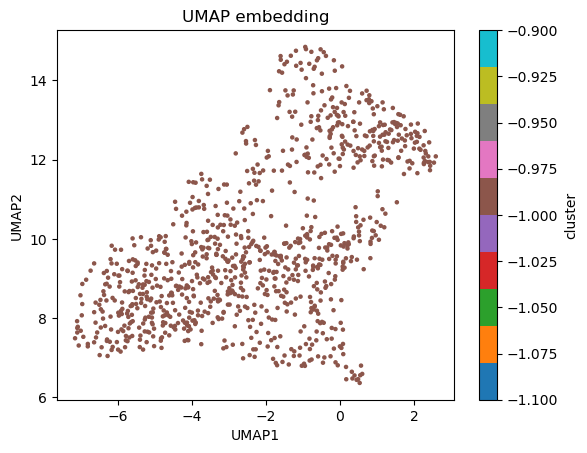

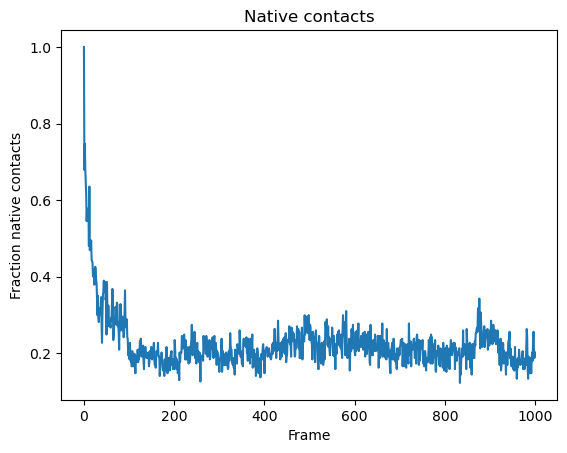

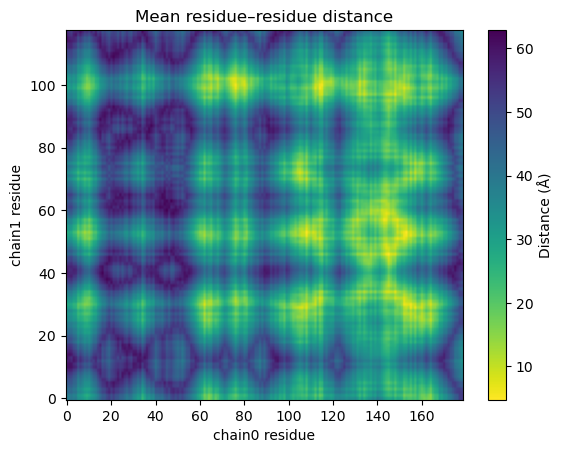

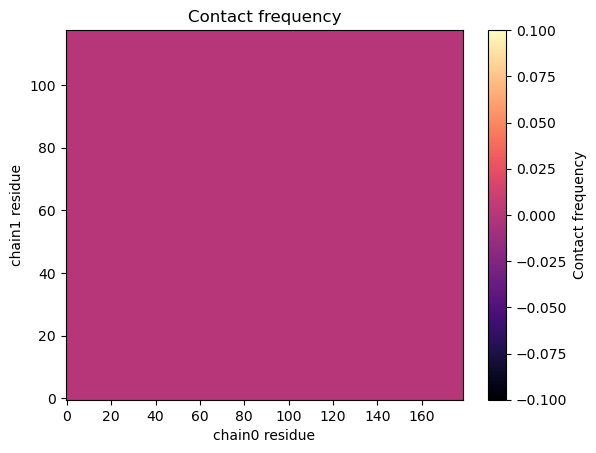

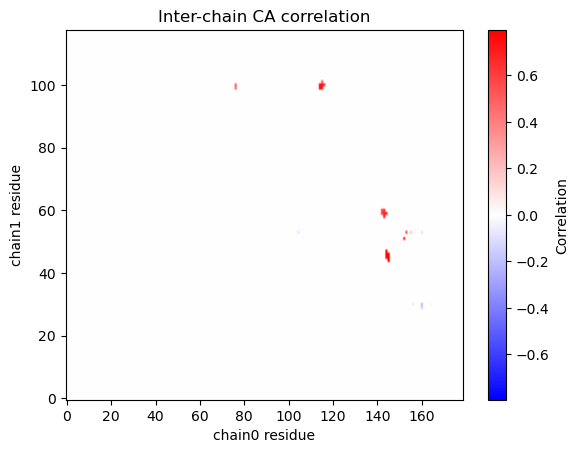

In [14]:
b = cam.analyze(BASE + "model.pdb", BASE + "trajectory.dcd", outputName="all_")
b.align(chain="A")
b.all("A", "B")
b.plotAll();